In [57]:
import numpy as np
import pandas as pd

In [58]:
df = pd.read_csv('spam.csv', encoding = 'latin1')

In [59]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3143,ham,"Haha I heard that, text me when you're around",NaN,NaN,NaN
2801,ham,And smile for me right now as you go and the w...,NaN,NaN,NaN
3572,spam,You won't believe it but it's true. It's Incre...,NaN,NaN,NaN
5336,ham,Sounds better than my evening im just doing my...,NaN,NaN,NaN
1099,ham,Been up to ne thing interesting. Did you have ...,NaN,NaN,NaN


In [60]:
df.shape

(5572, 5)

In [61]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [63]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [64]:
df.sample(5)

,v1,v2
4032,ham,I am taking you for italian food. How about a ...
984,ham,Yo guess what I just dropped
1877,ham,This pen thing is beyond a joke. Wont a Biro d...
4374,spam,Ur TONEXS subscription has been renewed and yo...
5130,ham,Any way where are you and what doing.


In [65]:
# renaming the columns
df.rename(columns={'v1' : 'Target' , 'v2' : 'Text'},inplace=True)
df.sample(5)

,Target,Text
3586,ham,Our ride equally uneventful - not too many of ...
1367,ham,"I don't know, same thing that's wrong everyso ..."
4112,ham,Thought we could go out for dinner. I'll treat...
2957,spam,U have a secret admirer. REVEAL who thinks U R...
4761,ham,Me too! Have a lovely night xxx


In [66]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [67]:
df['Target'] = encoder.fit_transform(df['Target'])

In [68]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [69]:
# missing values ?
df.isnull().sum()

Target    0
Text      0
dtype: int64

In [70]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [71]:
# remove Duplicate Values
df = df.drop_duplicates(keep = 'first')

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.shape

(5169, 2)

## 2. EDA

In [74]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [75]:
# here we will see how many ham/spam are there in our data
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

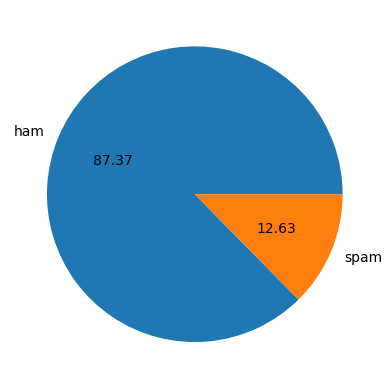

In [76]:
#here we will try to represent it with pie chart to see if our data is balanced or imbalanced
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [77]:
#we can clearly see that our data is imbalanced

In [78]:
!pip install nltk

In [79]:
import nltk

In [110]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chitr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\chitr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chitr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [81]:
#here we have importedthis library because we need3 more columns for no of characters, no of words, no of sentences

In [82]:
# for fetching no of characters
df['num_characters'] = df['Text'].apply(len)

In [83]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [84]:
# for fetching number of words
df['num_words'] = df['Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [85]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [86]:
# for number of sentences
df['num_sentences'] = df['Text'].apply(lambda x:len(nltk.sent_tokenize(x))) 

In [87]:
df.head()

,Target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [88]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [89]:
# we can analyse ham and spam seperately
# for ham messages
df[df['Target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [90]:
# for spam messages
df[df['Target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [91]:
import seaborn as sns

In [92]:
# now we will plot histogram for both ham/spam messages

<Axes: xlabel='num_characters', ylabel='Count'>

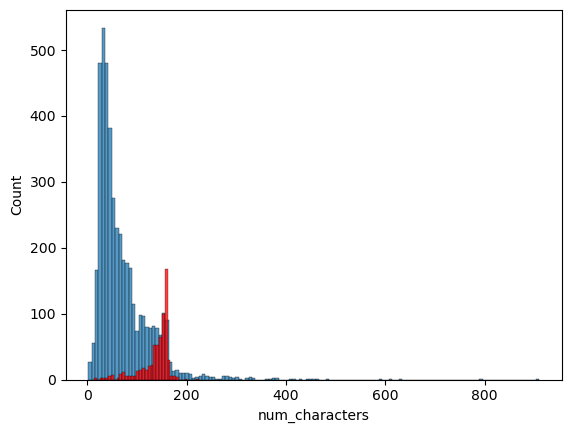

In [94]:
sns.histplot(df[df['Target'] == 0]['num_characters'])
sns.histplot(df[df['Target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

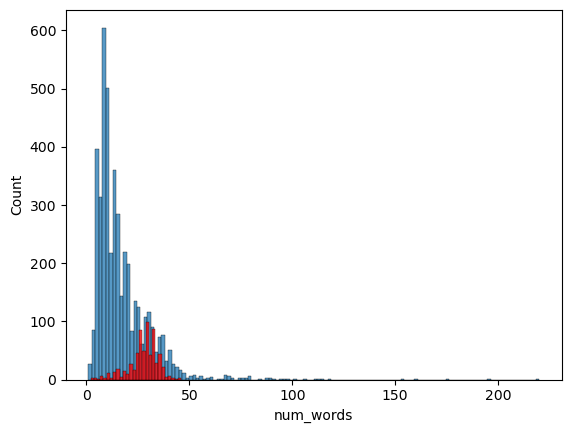

In [95]:
sns.histplot(df[df['Target'] == 0]['num_words'])
sns.histplot(df[df['Target'] == 1]['num_words'],color='red')

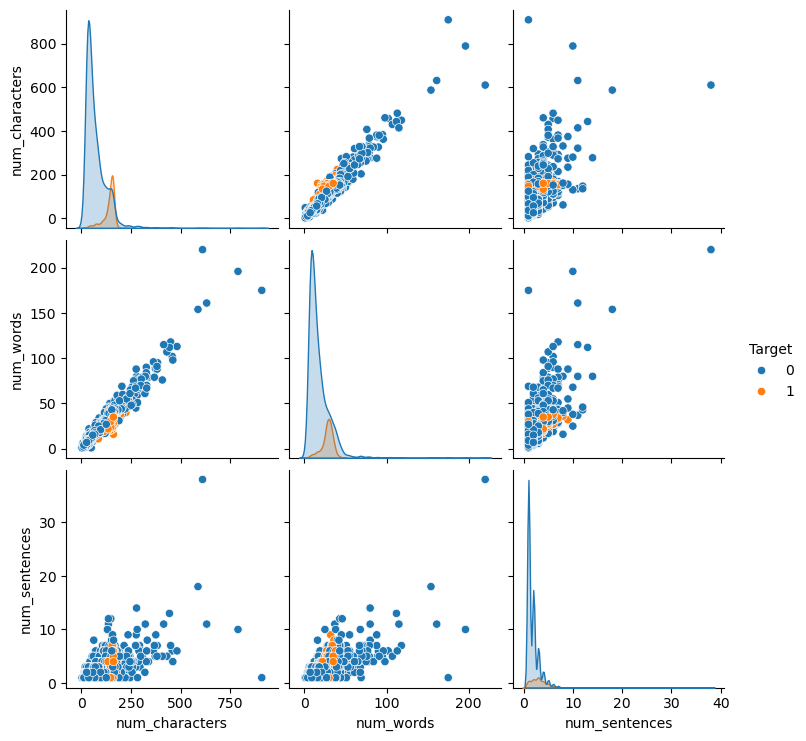

In [96]:
# for relation between num_characters and num_words
sns.pairplot(df, hue = 'Target')

<Axes: >

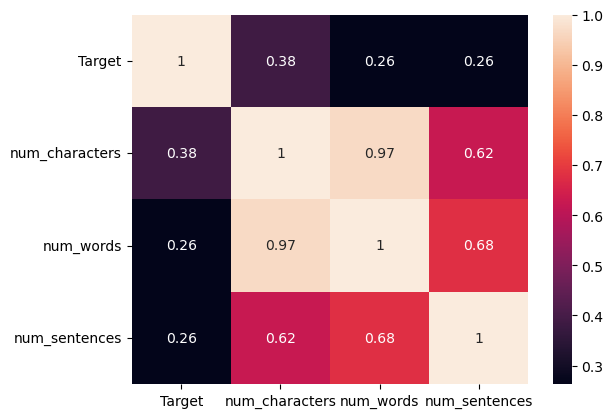

In [99]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## 3. Data Preprocessing

1. Lower Case
2. Tokenization (Breakdown in words and characters)
3. Remove special characters
4. Removing stop words and punctuation
5. Stemming (ek hi type ke words ko ek hi me assign kr dete ho , general word)

In [129]:
# Lower Casing the words
def transform_text(Text):
    Text = Text.lower()
    # tokenization
    Text = nltk.word_tokenize(Text)
    # Remove Special Characters (englih ya Alphanumeric)
    y = []
    for i in Text:
        if i.isalnum():
            y.append(i)

    Text = y[:]
    # upar jo kiya hai uska mtlb ye hai ki list ko aap kabhi bhi aise assign nhi kr skte kyuki list is mutable so we need to clone and assign like this
    y.clear()
    # remove stop words (jinka sentence formation me mtlb hota hai lkn genrealy meaning nhi hota is, are, etc)

    for i in Text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    Text = y[:]
    # further process of stemming
    y.clear()

    for i in Text:
        y.append(ps.stem(i))
        
    return " ".join(y)
    # here we want our returned output in form of string so we have done this...

In [130]:
transform_text("I loved the YT Lectures on Machine Learning. How about you?")

'love yt lectur machin learn'

In [131]:
# Stemming
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Loving')

'love'

In [132]:
df['transformed_text'] = df['Text'].apply(transform_text)

In [133]:
df.head()

,Target,Text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [137]:
# to install wordcloud as it is available in this version of JE
!pip install wordcloud

In [138]:
# ab wordcloud banayenge spam/ham messages ka jo hume used words batayega dono me
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [139]:
spam_wc = wc.generate(df[df['Target'] == 1]['transformed_text'].str.cat(sep = " "))

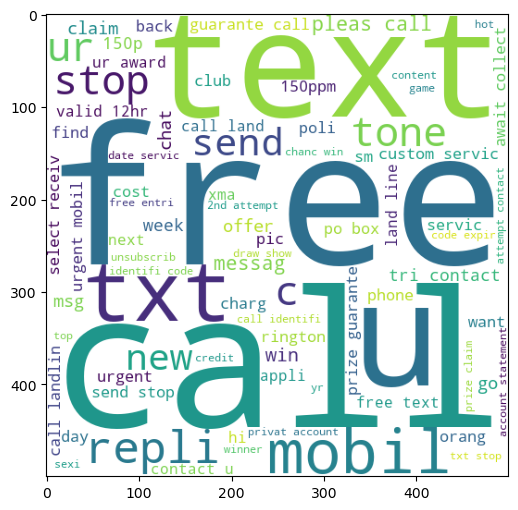

In [140]:
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)

In [141]:
# similarly for ham messages
ham_wc = wc.generate(df[df['Target'] == 0]['transformed_text'].str.cat(sep = " "))

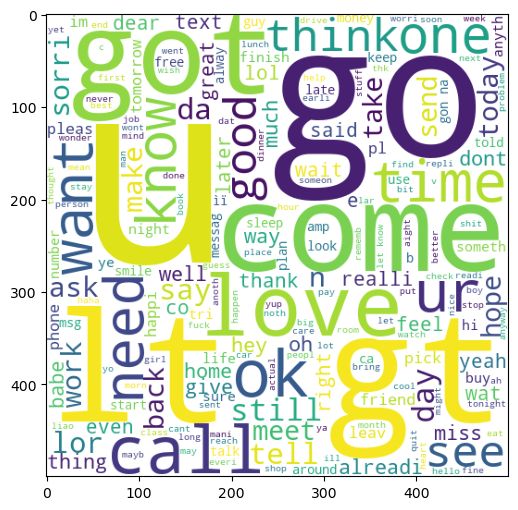

In [142]:
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)

In [143]:
df.head()

,Target,Text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [145]:
# dono ctaregories ke top 30 words
spam_corpus = []
for msg in df[df['Target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [146]:
len(spam_corpus)

9939

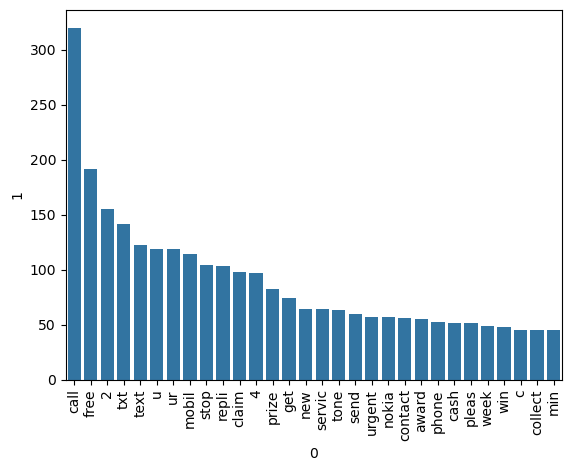

In [152]:
from collections import Counter
df_words = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x = df_words[0], y = df_words[1])
plt.xticks(rotation='vertical')
plt.show()

In [153]:
ham_corpus = []
for msg in df[df['Target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [154]:
len(ham_corpus)

35404

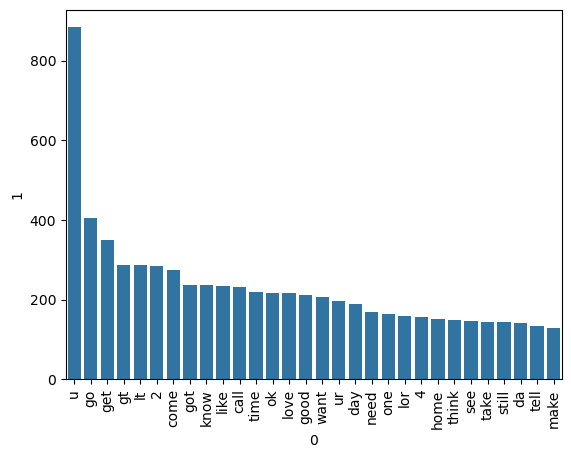

In [155]:
from collections import Counter
df_words = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x = df_words[0], y = df_words[1])
plt.xticks(rotation='vertical')
plt.show()

## 4. Model Building
  here we will use Naive Bayes algo as we know that in textual data it performs very well 
  and in addition we will compare some more models as which will be the best fit so we can use it

In [203]:
# jo humara nive base algo hai usme i/o numerical chahiye hota hai to humara o to numerical hai(Target) but input(transformed_text) nhi h
# so we will vectorize it using bag of words and later with tfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [204]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
#previously with cv

In [205]:
X.shape

(5169, 6708)

In [206]:
Y = df['Target'].values

In [207]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [208]:
from sklearn.model_selection import train_test_split

In [209]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [210]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [211]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [212]:
gnb.fit(X_train,Y_train)
Y_pred1 = gnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred1))
print(confusion_matrix(Y_test,Y_pred1))
print(precision_score(Y_test,Y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [213]:
# here above precision is very low so it is not performing well so we will check for another
mnb.fit(X_train,Y_train)
Y_pred2 = mnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred2))
print(confusion_matrix(Y_test,Y_pred2))
print(precision_score(Y_test,Y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [232]:
# here also above the precision is good in cv but we need to regularly search for better precision score and in tfidf it is excellent so we will go with this 
bnb.fit(X_train,Y_train)
Y_pred3 = bnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred3))
print(confusion_matrix(Y_test,Y_pred3))
print(precision_score(Y_test,Y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [233]:
# here precision score is highest with cv
#we have chosen tfidf -> MNB
# ab aur ML models ko MNB ses compare krenge aage 
!pip install xgboost

In [234]:
# ye almost sare Classification models hain
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [235]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [236]:
# yaha dictionary banayi jisme keys me algo names the and values me objects unke
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [237]:

def train_classifier(clf,X_train,Y_train,X_test,Y_test):
    clf.fit(X_train,Y_train)
    Y_pred = clf.predict(X_test)
    accuracy = accuracy_score(Y_test,Y_pred)
    precision = precision_score(Y_test,Y_pred)
    
    return accuracy,precision

In [238]:
train_classifier(svc,X_train,Y_train,X_test,Y_test)

(0.9729206963249516, 0.9741379310344828)

In [240]:
# ab isme maine ek loop chalya dictionary ke upr aur hr model ko train krke uska accuracy aur precision score store krta chla gya at the end for comparision
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,Y_train,X_test,Y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  KN
Accuracy -  0.9003868471953579
Precision -  1.0
For  NB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8380952380952381
For  LR
Accuracy -  0.9516441005802708
Precision -  0.94
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8409090909090909
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  GBDT
Accuracy -  0.9526112185686654
Precision -  0.9238095238095239
For  xgb
Accuracy -  0.9709864603481625
Precision -  0.9426229508196722


In [241]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [242]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,xgb,0.970986,0.942623
4,LR,0.951644,0.940000
9,GBDT,0.952611,0.923810
7,BgC,0.958414,0.862595
6,AdaBoost,0.924565,0.840909


In [243]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [244]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.900387
1,NB,Accuracy,0.959381
2,RF,Accuracy,0.971954
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.972921
5,xgb,Accuracy,0.970986
6,LR,Accuracy,0.951644
7,GBDT,Accuracy,0.952611
8,BgC,Accuracy,0.958414
9,AdaBoost,Accuracy,0.924565


In [ ]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()